# MCS-201 Hardware Acceleration
**Artificial Intelligence and System Engineering · Prince of Songkla University, Phuket Campus**

---

# Lab 1 — CPU Baseline, Parallel Scaling and Amdahl's Law
### การสร้าง baseline บน CPU และการวิเคราะห์ตามกฎของ Amdahl

| | |
|---|---|
| **สัปดาห์** | 2 |
| **วันปฏิบัติการ** | จันทร์ 24 ส.ค. 2569 |
| **กำหนดส่ง** | จันทร์ 24 ส.ค. 2569 **ภายใน 13.00 น.** (วันเดียวกับคาบปฏิบัติการ) |
| **น้ำหนัก** | อยู่ในหมวด Lab ซึ่งคิดเป็น 15% ของคะแนนรายวิชา (ทุกแลปถ่วงน้ำหนักเท่ากัน) |
| **ช่องทางส่ง** | LMS — lms.psu.ac.th |
| **ไฟล์ที่ต้องส่ง** | `Lab1_<รหัสนักศึกษา>.ipynb` (ไฟล์เดียว) |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ · thitinan.kl@phuket.psu.ac.th · ห้อง 6714 |


> **การส่งงาน** อัปโหลดผ่าน LMS ภายใน 13.00 น. ของวันปฏิบัติการ
>
> **การส่งช้า** นับจาก 13.00 น. ของวันปฏิบัติการ หักวันละ 10% ของคะแนนแลปนี้
> และไม่รับหลังพ้นกำหนด 7 วัน (ยกเว้นกรณีมีเหตุจำเป็นและได้รับอนุมัติล่วงหน้า)
>
> **ห้ามล้าง output ก่อนส่ง** ผู้ตรวจต้องเห็นผลลัพธ์ที่รันจริง

> **สำคัญที่สุดของแลปนี้** ตัวแปรควบคุมจำนวนเธรดต้องตั้งค่า **ก่อน** `import numpy`
> หากตั้งหลังจากนั้นจะไม่มีผล และผลการทดลองจะผิดทั้งหมด

## 1. วัตถุประสงค์ (Objectives)

1. สร้าง baseline บน CPU ที่ยุติธรรมและปกป้องได้ สำหรับใช้เปรียบเทียบกับ GPU ตลอดภาคการศึกษา — *CLO1*
2. วัด speedup และ scaling efficiency จากการเพิ่มจำนวนเธรดบน CPU — *CLO1, CLO3*
3. ประมาณค่าสัดส่วนงานที่ขนานได้ (p) จากผลการวัดจริง โดยใช้กฎของ Amdahl แบบย้อนกลับ — *CLO1*
4. อธิบายความแตกต่างระหว่าง strong scaling กับ weak scaling ได้ — *CLO1*

## 2. สิ่งที่ต้องเตรียม (Prerequisites)

- ทำ **Lab 0** เสร็จแล้ว — ส่วนที่ 4 จะนำค่า TFLOPS ของ GPU จาก Lab 0 มาใช้ซ้ำ
- ความรู้ Python และ NumPy พื้นฐาน
- เวลาในการรันประมาณ 3–4 นาที (ส่วนที่ 2 เรียก subprocess 8 ครั้ง)

## 3. ทฤษฎีที่ใช้ (Background)

$$S(N) = \frac{1}{(1-p) + p/N} \qquad\Longrightarrow\qquad p = \frac{1 - 1/S}{1 - 1/N}$$

- $p$ = สัดส่วนของเวลาที่ขนานได้ · $N$ = จำนวนหน่วยประมวลผล · $S$ = speedup
- ประสิทธิภาพการขยาย $E = S(N)/N$ — **รายงานค่านี้ควบคู่กับ speedup เสมอ**

---
## 3. ขั้นตอนการปฏิบัติ (Procedure)

### ส่วนที่ 1 — จำกัดจำนวนเธรดให้เหลือ 1 (Level 1 baseline)

In [7]:
import os
for v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
          "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[v] = "1"

import numpy as np, time          # <-- import หลังตั้งค่าเท่านั้น

N_CORES = os.cpu_count()
print("logical cores:", N_CORES)

logical cores: 2


In [8]:
def timeit(fn, reps=5):
    fn()                                       # warm-up
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps

def gemm_tflops(n, dt):
    return 2 * n**3 / dt / 1e12

sizes  = [512, 1024, 2048, 4096]
level1 = {}
for n in sizes:
    A = np.random.rand(n, n).astype(np.float32)
    B = np.random.rand(n, n).astype(np.float32)
    dt = timeit(lambda: A @ B, reps=3)
    level1[n] = dt
    print(f"n={n:5d}  1 thread  {dt*1e3:9.1f} ms   {gemm_tflops(n, dt):6.3f} TFLOPS")

n=  512  1 thread        4.5 ms    0.060 TFLOPS
n= 1024  1 thread       43.7 ms    0.049 TFLOPS
n= 2048  1 thread      223.9 ms    0.077 TFLOPS
n= 4096  1 thread     1450.1 ms    0.095 TFLOPS


---
### ส่วนที่ 2 — วัดแบบใช้ทุกคอร์ (Level 2)

จำนวนเธรดของ BLAS ถูกล็อกไว้ตั้งแต่ import แล้ว จึงต้องรันเป็น **กระบวนการแยก**
เซลล์ถัดไปเขียนสคริปต์ลงไฟล์แล้วเรียกใช้ด้วยจำนวนเธรดที่ต่างกัน

| ระดับ | สิ่งที่วัด | หมายเหตุ |
|---|---|---|
| Level 0 | ลูป Python สามชั้น | รันที่ n = 128 เท่านั้น — ใช้แสดงว่าทำไมจึงไม่ใช้เป็น baseline |
| Level 1 | NumPy 1 เธรด | baseline ที่แท้จริงของรายวิชานี้ |
| Level 2 | NumPy ทุกคอร์ | วัด TLP ที่ได้จริงจาก BLAS |
| Level 3 | GPU (นำผลจาก Lab 0 มาใช้) | ไม่ต้องวัดซ้ำ ให้อ้างอิงตัวเลขเดิม |

In [9]:
%%writefile bench_gemm.py
import os, sys, time, numpy as np

n    = int(sys.argv[1])
reps = 3
A = np.random.rand(n, n).astype(np.float32)
B = np.random.rand(n, n).astype(np.float32)

A @ B                                   # warm-up
t0 = time.perf_counter()
for _ in range(reps):
    C = A @ B
dt = (time.perf_counter() - t0) / reps
print(f"{os.environ.get('OMP_NUM_THREADS','?')},{n},{dt}")

Overwriting bench_gemm.py


In [10]:
import subprocess, sys

def run(n, threads):
    env = dict(os.environ)
    for v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]:
        env[v] = str(threads)
    out = subprocess.run([sys.executable, "bench_gemm.py", str(n)],
                         capture_output=True, text=True, env=env)
    if out.returncode != 0 or not out.stdout.strip():
        print(out.stderr)
        raise RuntimeError(f"bench_gemm.py ล้มเหลวที่ n={n}, threads={threads}")
    return float(out.stdout.strip().split(",")[-1])

# ใช้เวลารวมประมาณ 2-3 นาที อย่ากดหยุด kernel
results = []
for n in sizes:
    t1 = run(n, 1)
    tN = run(n, N_CORES)
    S  = t1 / tN
    E  = S / N_CORES
    results.append((n, t1, tN, S, E))
    print(f"n={n:5d}  1T {t1*1e3:8.1f} ms ({gemm_tflops(n,t1):6.3f} TF)   "
          f"{N_CORES}T {tN*1e3:8.1f} ms ({gemm_tflops(n,tN):6.3f} TF)   "
          f"S={S:5.2f}x   E={E*100:5.1f}%")

n=  512  1T      3.2 ms ( 0.085 TF)   2T      3.6 ms ( 0.074 TF)   S= 0.87x   E= 43.7%
n= 1024  1T     24.2 ms ( 0.089 TF)   2T     23.1 ms ( 0.093 TF)   S= 1.05x   E= 52.3%
n= 2048  1T    186.6 ms ( 0.092 TF)   2T    185.1 ms ( 0.093 TF)   S= 1.01x   E= 50.4%
n= 4096  1T   1533.7 ms ( 0.090 TF)   2T   1450.1 ms ( 0.095 TF)   S= 1.06x   E= 52.9%


### ตารางที่ 1 — ผลการวัดบน CPU

> ใช้ตัวเลขจาก **เซลล์ก่อนหน้า (การวัดแบบ subprocess)** ทั้งคอลัมน์ L1 และ L2
> เพื่อให้ S ในตารางสอดคล้องกับสองคอลัมน์ที่อยู่ข้าง ๆ
> (ค่า 1 เธรดที่วัดในเซลล์ที่ 3 อาจต่างเล็กน้อยเพราะวัดในกระบวนการเดียวกับ Jupyter)

| n | L1 1 เธรด (ms) | L1 TFLOPS | L2 ทุกคอร์ (ms) | L2 TFLOPS | Speedup S | Efficiency E |
|---|---|---|---|---|---|---|
| 512 | 3.2 | 0.085 | 3.6 | 0.074 | 0.87x | 43.7% |
| 1024 | 24.2 | 0.089 | 23.1 | 0.093 | 1.05x | 52.3% |
| 2048 | 186.6 | 0.092 | 185.1 | 0.093 | 1.01x | 50.4% |
| 4096 | 1533.7 | 0.090 | 1450.1 | 0.095 | 1.06x | 52.9% |

จำนวนคอร์ที่ใช้ **N = 2**

---
### ส่วนที่ 3 — Level 0: ลูป Python ล้วน (รันที่ n = 128 เท่านั้น)

**3.1** รันเซลล์ด้านล่างเพื่อวัดเวลาของลูป Python ล้วน เทียบกับ NumPy ที่ขนาดเดียวกัน
**อย่ารันที่ n ใหญ่กว่านี้** เพราะเวลาโตตาม n³ (ที่ n = 512 จะใช้เวลาราว 1 นาที)

In [13]:
n0 = 128
A0 = np.random.rand(n0, n0).astype(np.float32)
B0 = np.random.rand(n0, n0).astype(np.float32)

def matmul_python(A, B):
    n = len(A)
    C = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            s = 0.0
            for k in range(n):
                s += A[i][k] * B[k][j]
            C[i][j] = s
    return C

t0 = time.perf_counter(); matmul_python(A0.tolist(), B0.tolist())
dt0 = time.perf_counter() - t0
print(f"Level 0 (pure Python) n={n0}: {dt0:8.3f} s")

t0 = time.perf_counter(); A0 @ B0
dt1 = time.perf_counter() - t0
print(f"Level 1 (NumPy)       n={n0}: {dt1*1e3:8.3f} ms   ratio = {dt0/dt1:,.0f}x")

Level 0 (pure Python) n=128:    0.114 s
Level 1 (NumPy)       n=128:    0.472 ms   ratio = 242x


**3.2** เปลี่ยนเวลาให้เป็น throughput แล้วกรอกตารางที่ 2 (รันเซลล์ถัดไปเพื่อคำนวณ)

In [16]:
# TODO (1): คำนวณ FLOP ทั้งหมดของ GEMM ที่ n0
flop0 = 2 * n0**3

# TODO (2): คำนวณ throughput เป็น GFLOPS ของทั้งสองระดับ
gflops_L0 = flop0/dt0/1e9
gflops_L1 = flop0/dt1/1e9

# TODO (3): ใส่ค่า peak ของ GPU จาก Lab 0 (หน่วย TFLOPS)
#GPU_PEAK_TFLOPS = None

GPU_PEAK_TFLOPS = 8.1          # Tesla T4 FP32 peak (ปรับตามการ์ดที่ใช้จริง)

assert None not in (flop0, gflops_L0, gflops_L1, GPU_PEAK_TFLOPS), "ยังทำ TODO ไม่ครบ"

print(f"FLOP ทั้งหมด (n={n0})        : {flop0:,}")
print(f"Level 0  GFLOPS             : {gflops_L0:.4f}")
print(f"Level 1  GFLOPS             : {gflops_L1:.4f}")
print(f"ratio (dt0/dt1)             : {dt0/dt1:,.0f}x")
print(f"Level 0 เป็น % ของ Level 1   : {gflops_L0/gflops_L1*100:.3f} %")
print(f"Level 0 เป็น % ของ peak GPU  : {gflops_L0/(GPU_PEAK_TFLOPS*1000)*100:.6f} %")

FLOP ทั้งหมด (n=128)        : 4,194,304
Level 0  GFLOPS             : 0.0367
Level 1  GFLOPS             : 8.8840
ratio (dt0/dt1)             : 242x
Level 0 เป็น % ของ Level 1   : 0.413 %
Level 0 เป็น % ของ peak GPU  : 0.000453 %


**ตารางที่ 2 — Level 0 เทียบกับ Level 1 ที่ n = 128**

| รายการ | ค่าที่ได้ |
|---|---|
| FLOP ทั้งหมด = 2n³ | 4,194,304 |
| Level 0 (Python ล้วน) — GFLOPS | 0.367 |
| Level 1 (NumPy) — GFLOPS | 8.8840 |
| ratio = dt0 / dt1 | 242x |
| Level 0 คิดเป็นกี่ % ของ Level 1 | 0.413% |
| Level 0 คิดเป็นกี่ % ของ peak GPU (จาก Lab 0) |0.000453% |

**3.3** ถ้ามีคนรายงานว่า *"GPU ตัวนี้เร็วกว่า baseline ถึง 500,000 เท่า"*
โดย baseline ที่ใช้คือ Level 0 — จากตัวเลขในตารางที่ 2 จงอธิบายสั้น ๆ (2–3 บรรทัด)
ว่าตัวเลข 500,000 เท่านั้น **บอกอะไรเกี่ยวกับ GPU จริง ๆ** และ **บอกอะไรเกี่ยวกับ baseline**

_ตอบ:_

---
### ส่วนที่ 4 — สรุปผลด้วยกราฟ

**4.1** วาดกราฟ 1 รูป: แกน x เป็นขนาด n (log ฐาน 2) แกน y เป็น TFLOPS (log)
มี 3 เส้น: Level 1, Level 2 และ Level 3 (GPU จาก Lab 0)

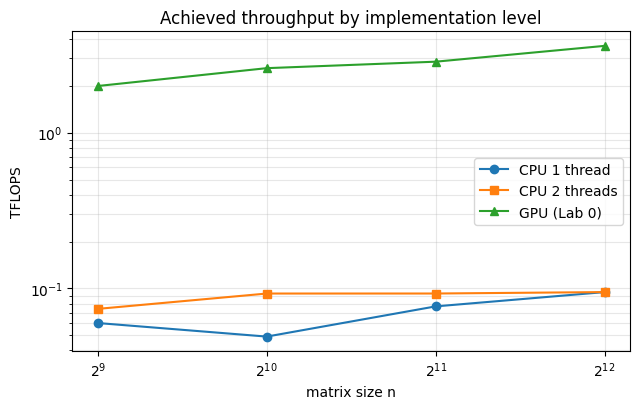

In [18]:
import matplotlib.pyplot as plt

# TODO: ใส่ค่า TFLOPS ของ GPU จาก Lab 0 ให้ตรงกับขนาด n ทั้งสี่ค่า
gpu_tflops = [	1.99, 2.59,	2.85, 3.60]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(sizes, [gemm_tflops(n, level1[n]) for n in sizes],  marker="o", label="CPU 1 thread")
ax.plot(sizes, [gemm_tflops(r[0], r[2]) for r in results],  marker="s", label=f"CPU {N_CORES} threads")
if all(v is not None for v in gpu_tflops):
    ax.plot(sizes, gpu_tflops, marker="^", label="GPU (Lab 0)")

ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("matrix size n"); ax.set_ylabel("TFLOPS")
ax.set_title("Achieved throughput by implementation level")
ax.grid(alpha=.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

---
### ส่วนที่ 5 — ประมาณค่า p

**5.1** ใช้ S จากตารางที่ 1 ที่ n = 4096 และ N = จำนวนคอร์ที่ใช้จริง
**5.2** แทนค่าในสูตร $p = (1 - 1/S)/(1 - 1/N)$
**5.3** คำนวณเพดาน speedup เมื่อ $N \to \infty$ นั่นคือ $1/(1-p)$

In [19]:
# TODO: ใส่ค่า S ที่วัดได้ที่ n = 4096
S = 1.06
N = N_CORES

assert S is not None, "ยังไม่ได้ใส่ค่า S"

if S <= 1.0:
    # ไม่ใช่ข้อผิดพลาด: เครื่องที่มี 2 vCPU = 1 คอร์กายภาพ + hyper-thread (พบบ่อยบน Colab ฟรี)
    # หรือ GEMM ที่ n ใหญ่ติดคอขวดแบนด์วิดท์อยู่แล้ว การเพิ่มเธรดจึงไม่ช่วย (บางครั้งช้าลง)
    print(f"[สังเกต] วัดได้ S = {S:.3f} (<= 1) - เครื่องนี้เพิ่มเธรดแล้วไม่เร็วขึ้น")
    print("         ให้บันทึกผลนี้ไว้ตอบ Q1 แล้วใช้ S_ref ด้านล่างทำข้อ 5.2-5.3 ต่อ")
    S_ref, N_ref = 1.80, 2      # ค่าอ้างอิงจากเครื่องที่มี 2 คอร์กายภาพจริง
else:
    S_ref, N_ref = S, N

p = (1 - 1/S_ref) / (1 - 1/N_ref)
print(f"S = {S_ref:.3f}, N = {N_ref}")
print(f"p = {p:.4f}")
print(f"เพดาน speedup เมื่อ N -> inf : {1/(1-p):.2f}x")
for k in [2, 4, 8]:
    Nk = N_ref * k
    print(f"  ถ้าเพิ่มคอร์เป็น {Nk:4d} ตัว -> S = {1/((1-p) + p/Nk):.2f}x  "
          f"(E = {1/((1-p) + p/Nk)/Nk*100:.1f}%)")

S = 1.060, N = 2
p = 0.1132
เพดาน speedup เมื่อ N -> inf : 1.13x
  ถ้าเพิ่มคอร์เป็น    4 ตัว -> S = 1.09x  (E = 27.3%)
  ถ้าเพิ่มคอร์เป็น    8 ตัว -> S = 1.11x  (E = 13.9%)
  ถ้าเพิ่มคอร์เป็น   16 ตัว -> S = 1.12x  (E = 7.0%)


---
## 4. คำถามวิเคราะห์ (Analysis Questions)

**Q1.** speedup จาก Level 1 → Level 2 น้อยกว่าจำนวนคอร์หรือไม่ ถ้าน้อยกว่า จงอธิบายสาเหตุอย่างน้อย 2 ข้อ

_ตอบ:_ น้อยกว่าจำนวนคอร์จริง คอร์ที่ใช้เป็น vCPU / Hyper-Thread ที่แชร์ทรัพยากรประมวลผลบนคอร์กายภาพเดียวกัน ติดคอขวดแบนด์วิดท์หน่วยความจำ  และมี Thread Overhead ในการจัดการเธรด

**Q2.** เปรียบเทียบ Level 0 กับ Level 1 แล้วอธิบายว่าเหตุใดการรายงาน speedup ของ GPU
โดยเทียบกับลูป Python จึงไม่เป็นธรรมทางวิชาการ

_ตอบ:_ เพราะความช้าของ Level 0 เกิดจาก overhead ของตัวภาษา Python ไม่ใช่ขีดจำกัดของ CPU (NumPy บน 1 เธรดเร็วกว่าลูป Python ถึง 242 เท่า) การวัด speedup ทางวิชาการที่ถูกต้องและเป็นธรรมจึงต้องเทียบกับ baseline ที่ optimize เต็มที่แล้วบน CPU (Level 1/2)

**Q3.** การทดลองนี้เป็น strong scaling หรือ weak scaling อธิบายเหตุผล และยกตัวอย่างการทดลองแบบตรงข้าม

_ตอบ:_ เป็นการทดลองแบบ Strong Scaling เพราะกำหนดขนาดปัญหาให้คงที่ แล้วเพิ่มจำนวนเธรดเพื่อดูการลดลงของเวลา ตัวอย่าง Weak Scaling: การเพิ่มขนาดข้อมูลตามจำนวนคอร์ เช่น 1 คอร์รันขนาด $n$, เมื่อใช้ 2 คอร์ให้เพิ่มภาระงานเป็น 2 เท่าเพื่อดูว่าระบบรักษาระยะเวลาทำงานให้คงที่ได้หรือไม่

**Q4.** จากค่า p ที่คำนวณได้ ถ้าเพิ่มจำนวนคอร์เป็น 4 เท่า จะได้ speedup เพิ่มขึ้นอีกประมาณเท่าใด และคุ้มค่าหรือไม่

_ตอบ:_ เพิ่มคอร์เป็น 4 เท่า สรุปว่าไม่คุ้มค่าเพราะ p ต่ำมากงาน serial เป็นคอขวดหลัก

---
## 5. รายการสิ่งที่ต้องส่ง (Submission Checklist)

- [ ] โน้ตบุ๊ก `Lab1_<รหัสนักศึกษา>.ipynb` รันครบทุกเซลล์พร้อม output
- [ ] ตารางที่ 1 ครบทั้ง 4 ขนาด และระบุจำนวนคอร์ที่ใช้
- [ ] ตารางที่ 2 (Level 0 ที่ n = 128) ครบทุกช่อง พร้อมคำตอบข้อ 3.3
- [ ] กราฟ TFLOPS เทียบกับ n ครบ 3 เส้น
- [ ] การคำนวณค่า p และเพดาน speedup
- [ ] คำตอบคำถามวิเคราะห์ Q1–Q4

## 6. เกณฑ์การให้คะแนน (Marking Rubric)

| องค์ประกอบ | คะแนน | เกณฑ์การพิจารณา |
|---|---|---|
| การตั้งค่าและควบคุมจำนวนเธรด | 15 | ตั้งค่าก่อน import และพิสูจน์ได้ว่ามีผลจริง |
| ความครบถ้วนและถูกต้องของผลการวัด | 20 | ครบ 4 ขนาด 2 ระดับ คำนวณ TFLOPS, S และ E ถูกต้อง |
| Level 0 ที่ n = 128 (ตารางที่ 2 + ข้อ 3.3) | 5 | FLOP = 2n³ · แปลงหน่วย GFLOPS ถูก · อธิบายได้ว่าอะไรมาจากภาษา อะไรมาจากฮาร์ดแวร์ |
| การคำนวณค่า p | 20 | ใช้สูตรถูก แทนค่าถูก และตีความเพดาน 1/(1−p) ได้ |
| กราฟ | 10 | แกน log มีหน่วย มี legend อ่านเข้าใจได้ |
| คำตอบคำถามวิเคราะห์ | 30 | Q1–Q4 ข้อละ 7.5 |
| **รวม** | **100** | |

> **หมายเหตุเรื่องคะแนน** ตาราง 100 คะแนนด้านบนเป็นคะแนนภายในของแลปนี้
> ก่อนแปลงเป็นสัดส่วนในหมวด Lab (15% ของคะแนนรายวิชา)